In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..") 
from load_data import load_league

In [132]:
LEAGUES = {
    "PL": "Premier League",
    "SA": "Serie A",
    "LL": "La Liga"
}

dfs = {}
for col, name in LEAGUES.items():
    df = load_league(col)
    df["League"] = name   
    dfs[col] = df

all_data = pd.concat(dfs.values(), ignore_index=True)

In [133]:
df.info()
df.isnull().mean()

<class 'pandas.DataFrame'>
RangeIndex: 3740 entries, 0 to 3739
Columns: 181 entries, Div to League
dtypes: datetime64[us](1), float64(156), int64(16), str(8)
memory usage: 5.2 MB


Div         0.000000
Date        0.000000
HomeTeam    0.000000
AwayTeam    0.000000
FTHG        0.000000
              ...   
LBCH        0.936631
LBCD        0.936631
LBCA        0.936631
Season      0.000000
League      0.000000
Length: 181, dtype: float64

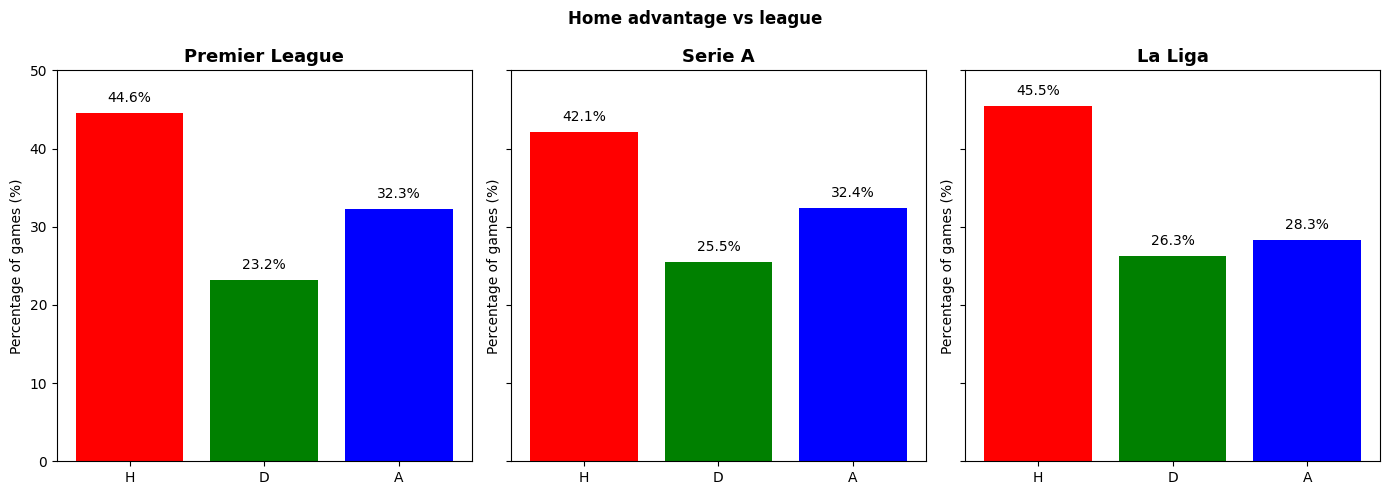

In [134]:
COLORS = ['r', 'g', 'b']
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

fig.suptitle('Home advantage vs league', fontweight='bold')

for ax, (league, name) in zip(axes, LEAGUES.items()):
    df = load_league(league)
 
    counts = df['FTR'].value_counts(normalize=True) * 100
    # H - home, D - draw, A - away
    order = ['H', 'D', 'A']
    values = [counts.get(o, 0) for o in order]
    bars = ax.bar(order, values, color=COLORS)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_ylabel('Percentage of games (%)')
    ax.set_ylim(0, 50)  
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

fig.tight_layout()
plt.show()

In [135]:
def add_form(df, n_matches=5):
    """Calculates team's form (points and goal difference) from last n games."""
    df = df.sort_values('Date').reset_index(drop=True)
    
    team_history = {}
    home_form_pts = []
    away_form_pts = []
    home_goal_diff = []
    away_goal_diff = []
    
    for _, row in df.iterrows():
        home = row['HomeTeam']
        away = row['AwayTeam']
        
        for team in [home, away]:
            if team not in team_history:
                team_history[team] = {'points': [], 'goal_diff': []}
        
        # points in last n games
        home_pts = sum(team_history[home]['points'][-n_matches:])
        away_pts = sum(team_history[away]['points'][-n_matches:])
        home_form_pts.append(home_pts)
        away_form_pts.append(away_pts)
        
        # goal diff in last n games
        home_gd = sum(team_history[home]['goal_diff'][-n_matches:])
        away_gd = sum(team_history[away]['goal_diff'][-n_matches:])
        home_goal_diff.append(home_gd)
        away_goal_diff.append(away_gd)
        
        # points update after each game
        if row['FTR'] == 'H':
            team_history[home]['points'].append(3)
            team_history[away]['points'].append(0)
        elif row['FTR'] == 'A':
            team_history[home]['points'].append(0)
            team_history[away]['points'].append(3)
        else:
            team_history[home]['points'].append(1)
            team_history[away]['points'].append(1)
        
        # goal diff update
        home_goals = row['FTHG']
        away_goals = row['FTAG']
        team_history[home]['goal_diff'].append(home_goals - away_goals)
        team_history[away]['goal_diff'].append(away_goals - home_goals)
    
    df[f'home_form_{n_matches}'] = home_form_pts
    df[f'away_form_{n_matches}'] = away_form_pts
    df[f'form_diff_{n_matches}'] = df[f'home_form_{n_matches}'] - df[f'away_form_{n_matches}']
    
    df[f'home_gd_{n_matches}'] = home_goal_diff
    df[f'away_gd_{n_matches}'] = away_goal_diff
    df[f'gd_diff_{n_matches}'] = df[f'home_gd_{n_matches}'] - df[f'away_gd_{n_matches}']
    
    return df

In [136]:
N_GAMES = [5, 10, 15]

dfs_form = {}

for league, name in LEAGUES.items():
    df = load_league(league)
    for n in N_GAMES:
        df = add_form(df, n_matches=n)
    dfs_form[league] = df

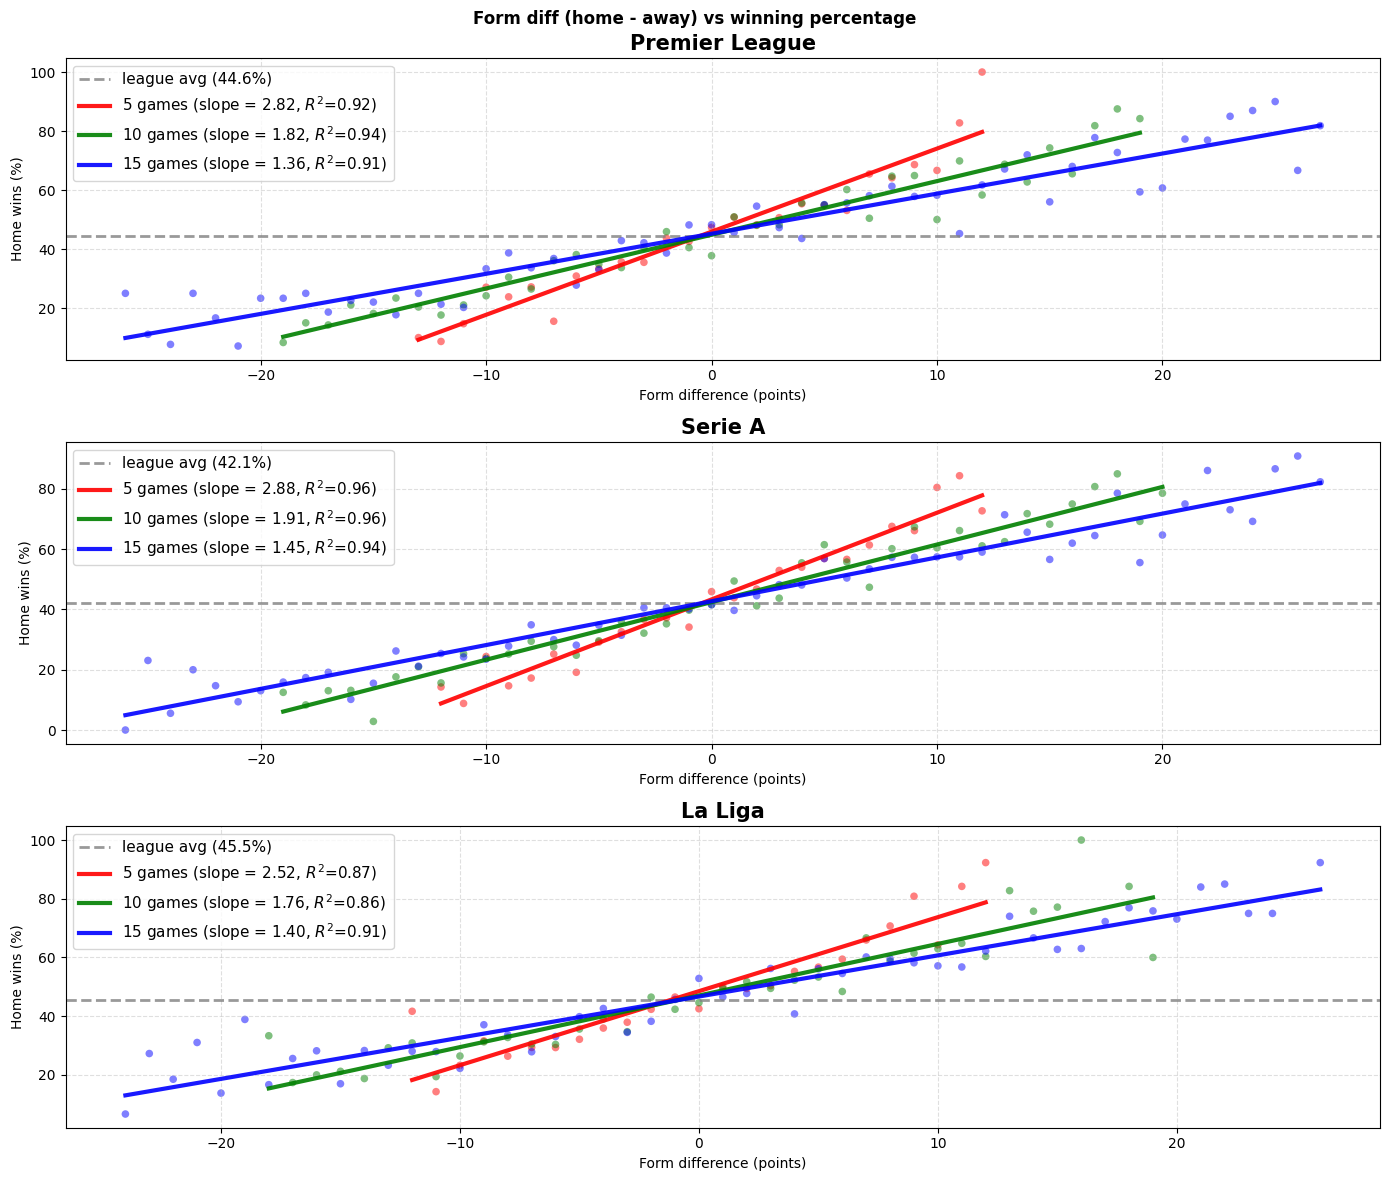

In [137]:
from scipy.stats import linregress

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharey=False)
fig.suptitle('Form diff (home - away) vs winning percentage', fontweight='bold')

for ax, (league, name) in zip(axes, LEAGUES.items()):
    df = dfs_form[league]
    overall_home_win_pct = (df['FTR'] == 'H').mean() * 100

    # average line
    ax.axhline(y=overall_home_win_pct, color='gray', linestyle='--',
               linewidth=2, alpha=0.8, label=f'league avg ({overall_home_win_pct:.1f}%)')

    for n, color in zip(N_GAMES, COLORS):
        col = f'form_diff_{n}'
        grouped = df.groupby(col)['FTR'].apply(lambda x: (x == 'H').mean() * 100)
        counts = df.groupby(col).size()
        valid = counts >= 10    # significant results 
        grouped = grouped[valid]

        if len(grouped) < 2:
            continue

        x = grouped.index.values
        y = grouped.values

        
        ax.scatter(x, y, color=color, s=30, alpha=0.5, edgecolors='none')


        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, '-', color=color, linewidth=3, alpha=0.9,
                label=f'{n} games (slope = {slope:.2f}, $R^2$={r_squared:.2f})')

    ax.set_title(name, fontsize=15, fontweight='bold')
    ax.set_xlabel('Form difference (points)')
    ax.set_ylabel('Home wins (%)')
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=11, loc='upper left')

fig.tight_layout()
plt.show()

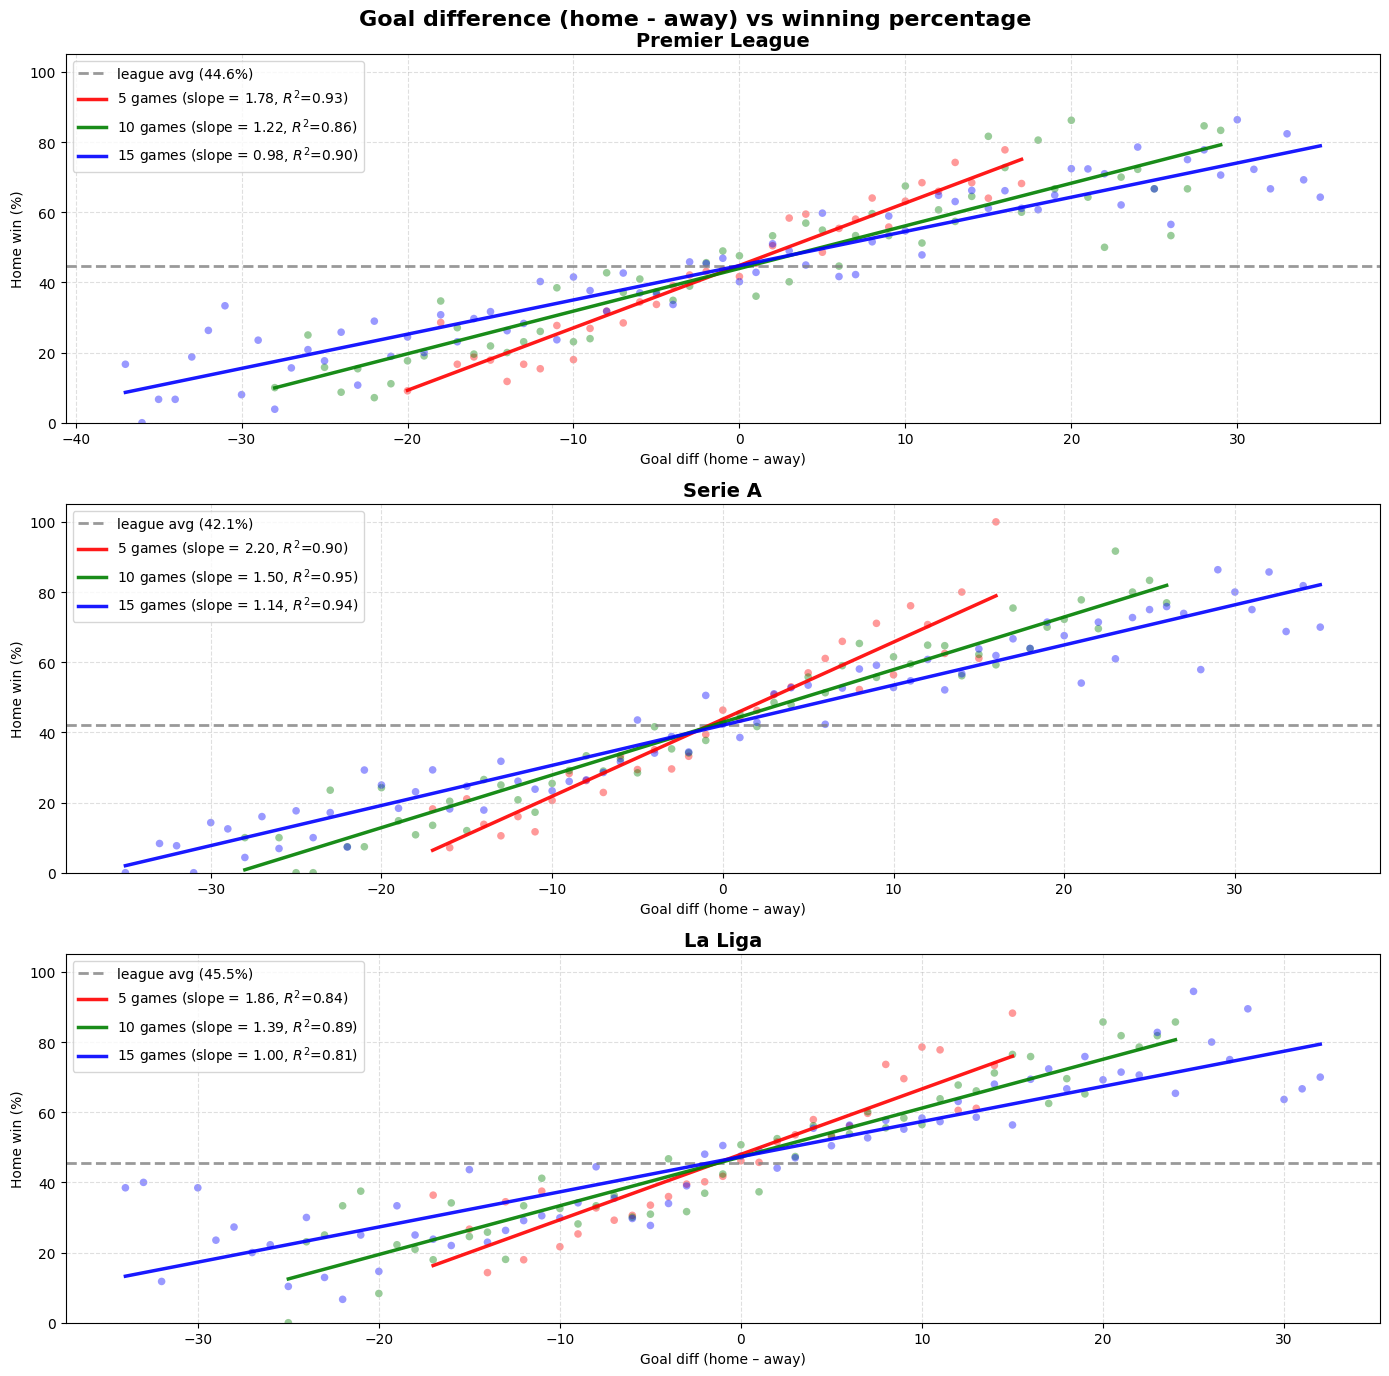

In [ ]:

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Goal difference (home - away) vs winning percentage',
             fontsize=16, fontweight='bold')

for ax, (league, name) in zip(axes, LEAGUES.items()):
    df = dfs_form[league]
    overall_home_win_pct = (df['FTR'] == 'H').mean() * 100


    ax.axhline(y=overall_home_win_pct, color='gray', linestyle='--',
               linewidth=2, alpha=0.8, label=f'league avg ({overall_home_win_pct:.1f}%)')

    for n, color in zip(N_GAMES, COLORS):
        col = f'gd_diff_{n}'                    

        grouped = df.groupby(col)['FTR'].apply(lambda x: (x == 'H').mean() * 100)
        counts = df.groupby(col).size()
        valid = counts >= 10
        grouped = grouped[valid]

        if len(grouped) < 2:
            continue

        x = grouped.index.values
        y = grouped.values

        ax.scatter(x, y, color=color, s=30, alpha=0.4, edgecolors='none')

        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, '-', color=color, linewidth=2.5, alpha=0.9,
                label=f'{n} games (slope = {slope:.2f}, $R^2$={r_squared:.2f})')

    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Goal diff (home – away)')
    ax.set_ylabel('Home win (%)')
    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(fontsize=10, loc='upper left')
    ax.set_ylim(0, 105)

fig.tight_layout()
plt.show()

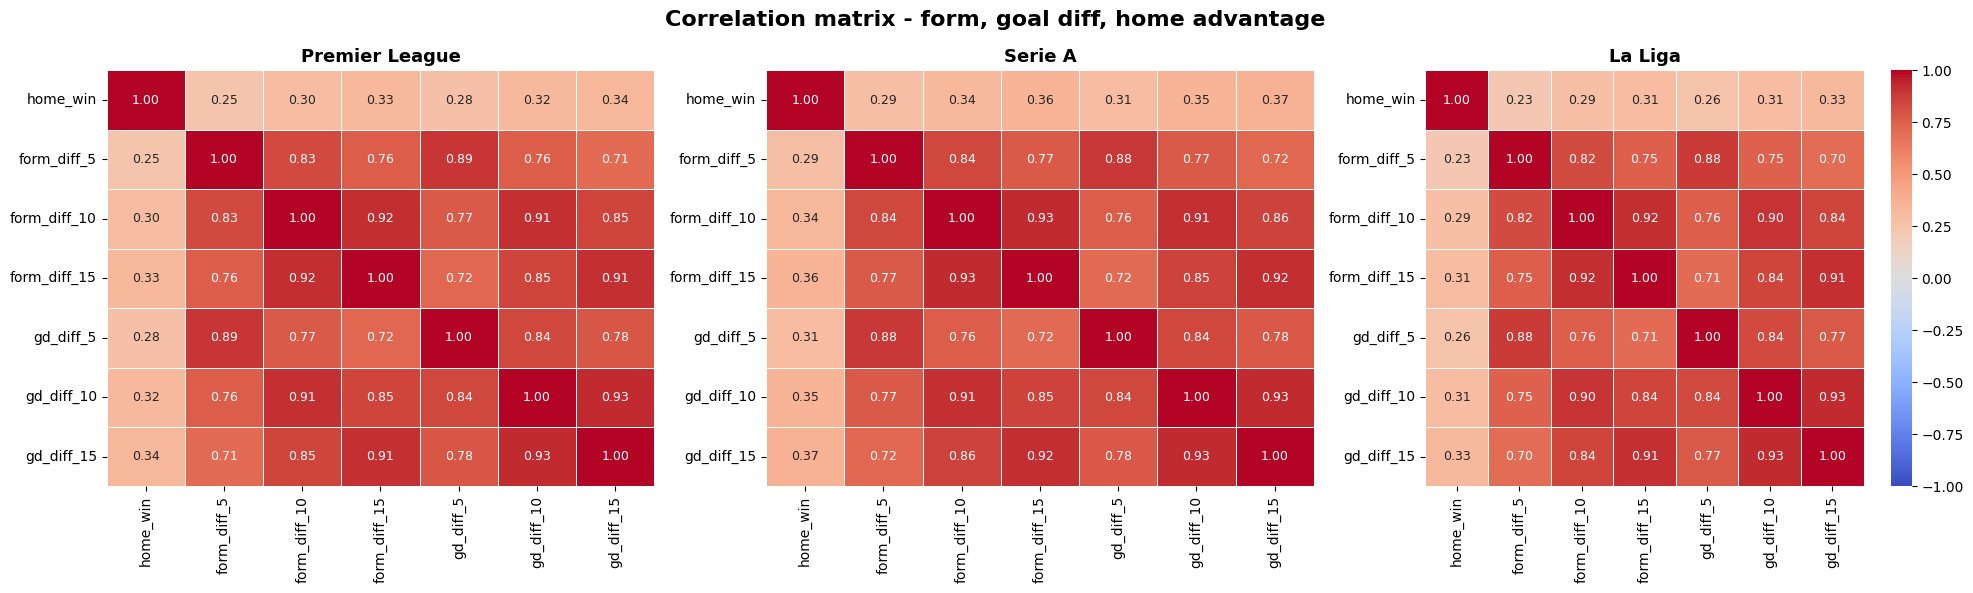

In [ ]:
import seaborn as sns

for league in LEAGUES:
    dfs_form[league]['home_win'] = (dfs_form[league]['FTR'] == 'H').astype(int)

features = [
    'form_diff_5', 'form_diff_10', 'form_diff_15',
    'gd_diff_5', 'gd_diff_10', 'gd_diff_15',
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Correlation matrix - form, goal diff, home advantage',
             fontsize=16, fontweight='bold')

for ax, (league, name) in zip(axes, LEAGUES.items()):
    df = dfs_form[league]
    corr_df = df[['home_win'] + features].corr()
    
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                ax=ax, cbar=(league == 'LL'), vmin=-1, vmax=1,
                linewidths=0.5, annot_kws={"size": 9})
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()